# EEGNet Pytorch 

### Import libraries

In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import StratifiedGroupKFold
import torch

### 1. Prepare the data 

In [30]:
# Load preprocessed data
df = pd.read_pickle("preprocessed_data_CNN.pkl")

# Select EEG channel columns
channel_cols = [col for col in df.columns if col.startswith("EEG")]

# Inputs for the split
X = df[channel_cols]
y = df["epilepsy"].astype(int)  # make sure it's int (0 or 1)
groups = df["subject_id"]

# Create EEG tensor (n_trials, n_channels, n_samples)
X_tensor = np.stack([np.stack(X[col].values) for col in channel_cols], axis=1)  # (n_trials, n_channels, n_samples)
X_tensor = X_tensor[..., np.newaxis]  # (n_trials, n_channels, n_samples, 1)

# Normalize per trial (recommended)
X_tensor = (X_tensor - np.mean(X_tensor, axis=2, keepdims=True)) / np.std(X_tensor, axis=2, keepdims=True)

# Patient-level stratified split (first fold only)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in sgkf.split(X_tensor, y, groups):
    X_train, X_test = X_tensor[train_idx], X_tensor[test_idx]
    y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values
    break  # use only first fold

# Convert to PyTorch tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)  # (B, 1, C, T)
X_test_torch = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_torch = torch.tensor(y_train, dtype=torch.long)  # shape (B,)
y_test_torch = torch.tensor(y_test, dtype=torch.long)

print("✅ Patient-level split done:")
print("X_train:", X_train_torch.shape, " y_train:", y_train_torch.shape)
print("X_test :", X_test_torch.shape, " y_test :", y_test_torch.shape)


✅ Patient-level split done:
X_train: torch.Size([864, 1, 21, 1250])  y_train: torch.Size([864])
X_test : torch.Size([162, 1, 21, 1250])  y_test : torch.Size([162])


In [31]:
df.head()

,epoch,EEG FP1-REF,EEG FP2-REF,EEG F3-REF,EEG F4-REF,EEG C3-REF,EEG C4-REF,EEG P3-REF,EEG P4-REF,EEG O1-REF,...,EEG T1-REF,EEG T2-REF,EEG FZ-REF,EEG CZ-REF,EEG PZ-REF,epilepsy,age,gender,edf_path,subject_id
0,0,"[-0.01784385366087909, -0.2319206729704393, -0...","[-0.019844846013779928, -0.05460307805555949, ...","[0.014159427135305987, -0.827987858316483, -1....","[0.026627355098365533, -0.9790399599687344, -1...","[0.024982564687609014, -0.360776949156545, -0....","[4.018909239838109e-05, 0.4516521336738522, 0....","[0.018403085976989437, -0.08535470666687679, -...","[-0.0011044371395921592, 0.58501523776895, 0.9...","[0.006761679494165433, 0.2648958897114391, 0.3...",...,"[-0.0034274171282873645, -0.5757413029048704, ...","[-0.0003171746056008312, 0.20722619010681073, ...","[0.013814359314612622, -0.5783915356525691, -1...","[0.005210932970110423, 0.2199463130977196, 0.1...","[0.009069977977880598, 0.33020551843690166, 0....",0,57,F,data/01_no_epilepsy/aaaaamhx/s001_2011/01_tcp_...,aaaaamhx
1,1,"[-0.8181898183675405, -1.0124068650379672, -1....","[-0.7407518252763884, -0.9426607600311053, -1....","[-0.10728587988186837, -0.16136806526801772, 0...","[0.7641939374140267, 0.4764694402788351, -0.39...","[0.531350680331542, 1.093930046707938, 1.99175...","[0.6348436862387128, 1.1517975711786905, 1.574...","[0.4714122324229238, 1.1689507320223047, 1.935...","[0.18768678442343795, 0.8809502496569463, 1.52...","[0.40951724382027394, 0.9235910451050278, 1.43...",...,"[0.029479305075569034, 0.26479945086845913, 0....","[-0.09310295233384792, 0.1651956034269939, 0.4...","[-0.7713124695192367, -0.9687413280323001, -0....","[-0.03627436517606299, 0.6818886293913989, 1.7...","[0.27838706412143494, 1.0985911792019396, 1.95...",0,57,F,data/01_no_epilepsy/aaaaamhx/s001_2011/01_tcp_...,aaaaamhx
2,2,"[1.6030538672881443, 2.0073574358736503, 2.299...","[1.6347041671500178, 1.8573993199742986, 2.084...","[2.022959660293185, 2.224064408239876, 2.35502...","[0.9965966450613225, 1.1553432485845934, 0.983...","[0.9202394443075629, 0.6799414833225241, 0.812...","[-1.1475031283720605, -1.3785676999992875, -1....","[-0.1382645053340494, -0.42366343781396576, -0...","[-1.5742036845448093, -1.6649664163783051, -1....","[-0.20873750710821382, -0.24880715073799636, -...",...,"[0.9734625896924435, 1.0546102501177088, 1.179...","[0.3833353520338253, 0.36690355118048856, 0.40...","[1.09190623411826, 1.5291034990739139, 2.25000...","[-0.9181756601045967, -1.3197607854610782, -1....","[-1.122857522515751, -1.4678830954474056, -1.3...",0,57,F,data/01_no_epilepsy/aaaaamhx/s001_2011/01_tcp_...,aaaaamhx
3,3,"[-1.477673892455215, -1.6220937945975127, -1.6...","[-1.483593369603851, -1.5484131884285148, -1.5...","[-1.90258767991592, -1.3030264916302363, -0.30...","[-0.3526049844663006, 0.37967261600646884, 0.9...","[-1.6922140879356857, -1.589625535577452, -0.9...","[0.32997755263377077, -0.20057347755383093, -0...","[-0.7370440393635136, -1.1278778377837304, -1....","[0.14740001476017742, -0.19636637527494324, 0....","[-0.41130356856736694, -0.8698401162842634, -0...",...,"[-0.40712504898913904, -0.4035768496313453, -0...","[-0.2270061941355091, -0.5316070332032854, -0....","[-0.7077960349925579, -0.6111049095117103, -0....","[-0.22926451454312752, -0.7192222022037064, -0...","[-0.4833460619178825, -0.9664910031020261, -0....",0,57,F,data/01_no_epilepsy/aaaaamhx/s001_2011/01_tcp_...,aaaaamhx
4,4,"[0.11051189890620886, -0.5138913354865124, -0....","[0.04879732296606088, -0.1807046740721547, -0....","[0.8381954178224904, -0.48077914083147727, -1....","[-0.4462134284717367, 0.09155566224947255, -0....","[0.9511474597656614, -0.5004750442592082, -1.3...","[0.04491578199848564, -0.4372731292602868, -0....","[0.6851261820450308, -0.6800937333527124, -1.6...","[-0.23837709107859806, -0.8332581824237363, -1...","[0.5528750242041535, -0.6642719632258031, -1.4...",...,"[1.3521492481513253, -0.21674576829431658, -1....","[-1.236499534875852, -1.2774578948046311, -1.1...","[-1.

In [32]:
len(df.iloc[0]["EEG P3-REF"]) #n_samples 

1250

### 2. EEGNet Model

In [33]:
import torch.nn as nn
import torch.nn.functional as F

class EEGNet(nn.Module):
    def __init__(self, n_channels=21, n_samples=1250, num_classes=2, dropout_rate=0.5):
        super(EEGNet, self).__init__()

        # Temporal convolution: learn temporal filters across time dimension
        self.firstconv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=(1, 64), padding=(0, 32), bias=False),  # shape: (B, 8, C, T)
            nn.BatchNorm2d(8)
        )

        # Depthwise spatial convolution: one spatial filter per temporal filter
        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=(n_channels, 1), groups=8, bias=False),  # shape: (B, 16, 1, T)
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout_rate)
        )

        # Separable convolution: combines temporal filters again
        self.separableConv = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate)
        )

        # Dynamically compute the flattened feature size after conv layers
        dummy_input = torch.zeros(1, 1, n_channels, n_samples)
        with torch.no_grad():
            x = self.firstconv(dummy_input)
            x = self.depthwiseConv(x)
            x = self.separableConv(x)
            flattened_size = x.reshape(1, -1).shape[1]  # dynamically computed

        # Final classification layer
        self.classifier = nn.Linear(flattened_size, num_classes)

    def forward(self, x):
        x = self.firstconv(x)
        x = self.depthwiseConv(x)
        x = self.separableConv(x)
        x = x.reshape(x.size(0), -1)  # flatten
        x = self.classifier(x)
        return x


### 3. Model training

In [34]:
# Create model
model = EEGNet(n_channels=21, n_samples=1250, num_classes=2)

# Move model and data to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
X_train_torch, y_train_torch = X_train_torch.to(device), y_train_torch.to(device)
X_test_torch, y_test_torch = X_test_torch.to(device), y_test_torch.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()  # suitable for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # adaptive learning rate


### 4. Training loop

In [35]:
from sklearn.metrics import confusion_matrix

# Initialize tracking
train_accuracies, test_accuracies = [], []
train_sensitivities, test_sensitivities = [], []
train_specificities, test_specificities = [], []
train_losses = []

best_acc = 0.0
best_model_path = "best_model.pth"
n_epochs = 30
batch_size = 32

for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    total_loss = 0
    train_preds, train_targets = [], []

    for i in range(0, X_train_torch.size(0), batch_size):
        idx = perm[i:i+batch_size]
        x_batch, y_batch = X_train_torch[idx], y_train_torch[idx]

        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Store train predictions for metrics
        train_preds.append(output.argmax(dim=1).cpu())
        train_targets.append(y_batch.cpu())

    # Flatten lists of predictions
    train_preds = torch.cat(train_preds).numpy()
    train_targets = torch.cat(train_targets).numpy()

    # Train metrics
    train_acc = (train_preds == train_targets).mean()
    tn, fp, fn, tp = confusion_matrix(train_targets, train_preds).ravel()
    train_sens = tp / (tp + fn)
    train_spec = tn / (tn + fp)

    train_accuracies.append(train_acc)
    train_sensitivities.append(train_sens)
    train_specificities.append(train_spec)
    train_losses.append(total_loss)

    # Eval
    model.eval()
    with torch.no_grad():
        output = model(X_test_torch)
        test_preds = output.argmax(dim=1).cpu().numpy()
        test_targets = y_test_torch.cpu().numpy()

        test_acc = (test_preds == test_targets).mean()
        tn, fp, fn, tp = confusion_matrix(test_targets, test_preds).ravel()
        test_sens = tp / (tp + fn)
        test_spec = tn / (tn + fp)

        test_accuracies.append(test_acc)
        test_sensitivities.append(test_sens)
        test_specificities.append(test_spec)

        # Save best model
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"💾 Saved best model at epoch {epoch+1} (acc={test_acc:.4f})")

    # Print metrics per epoch
    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train Acc: {train_acc:.4f}  Sens: {train_sens:.4f}  Spec: {train_spec:.4f} | "
          f"Test Acc: {test_acc:.4f}  Sens: {test_sens:.4f}  Spec: {test_spec:.4f}")


💾 Saved best model at epoch 1 (acc=0.2346)
Epoch 1/30 | Train Acc: 0.5995  Sens: 0.8202  Spec: 0.2424 | Test Acc: 0.2346  Sens: 0.7500  Spec: 0.1449
💾 Saved best model at epoch 2 (acc=0.3519)
Epoch 2/30 | Train Acc: 0.6609  Sens: 0.9045  Spec: 0.2667 | Test Acc: 0.3519  Sens: 0.8333  Spec: 0.2681
💾 Saved best model at epoch 3 (acc=0.4877)
Epoch 3/30 | Train Acc: 0.7049  Sens: 0.8989  Spec: 0.3909 | Test Acc: 0.4877  Sens: 0.7083  Spec: 0.4493
💾 Saved best model at epoch 4 (acc=0.6728)
Epoch 4/30 | Train Acc: 0.7257  Sens: 0.8408  Spec: 0.5394 | Test Acc: 0.6728  Sens: 0.7083  Spec: 0.6667
💾 Saved best model at epoch 5 (acc=0.7407)
Epoch 5/30 | Train Acc: 0.7905  Sens: 0.8858  Spec: 0.6364 | Test Acc: 0.7407  Sens: 0.8750  Spec: 0.7174
Epoch 6/30 | Train Acc: 0.8067  Sens: 0.8858  Spec: 0.6788 | Test Acc: 0.6852  Sens: 0.8750  Spec: 0.6522
💾 Saved best model at epoch 7 (acc=0.7654)
Epoch 7/30 | Train Acc: 0.8264  Sens: 0.8895  Spec: 0.7242 | Test Acc: 0.7654  Sens: 0.8333  Spec: 0.7536


In [36]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

def aggregate_predictions_dl(model, segment_df, feature_cols, 
                             id_col='subject_id', label_col='epilepsy', 
                             threshold=0.5, device='cpu', batch_size=32):
    """
    Aggregates 5-second EEG segment predictions into subject-level predictions 
    using a deep learning model (e.g., EEGNet).

    Parameters:
    - model: Trained PyTorch model
    - segment_df: DataFrame with EEG segments and metadata (must include subject_id and features)
    - feature_cols: List of EEG channel columns (each row = 1 segment)
    - id_col: Column identifying unique EEG recordings (e.g. subject_id or edf_path)
    - label_col: Ground-truth column name
    - threshold: Classification threshold (default 0.5 for binary)
    - device: 'cuda' or 'cpu'
    - batch_size: Number of segments per inference batch

    Returns:
    - agg_df: DataFrame with one row per subject/recording:
        - subject_id / edf_path
        - number_of_segments
        - mean_probability
        - predicted_label
        - true_label
    """

    model.eval()                      # Set model to eval mode
    model.to(device)                 # Send model to device (GPU or CPU)
    segment_df = segment_df.copy()  # Avoid modifying original df

    all_probs = []   # Store segment-level probabilities
    all_ids = []     # Store subject IDs corresponding to each prediction

    with torch.no_grad():  # Disable gradient computation for speed
        for i in range(0, len(segment_df), batch_size):
            batch = segment_df.iloc[i:i+batch_size]

            # Extract EEG arrays and stack into tensor: (B, C, T)
            eeg_batch = np.stack([np.stack(row) for row in batch[feature_cols].values])

            # Reshape to (B, 1, C, T) — EEGNet expects channel-first
            eeg_batch = eeg_batch[:, np.newaxis, :, :]  # Add dummy input channel

            # Convert to torch tensor and send to GPU/CPU
            eeg_batch = torch.tensor(eeg_batch, dtype=torch.float32).to(device)

            # Run model to get class logits
            logits = model(eeg_batch)

            # Convert logits to probabilities for class 1 (epilepsy)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

            # Store probs and IDs
            all_probs.extend(probs)
            all_ids.extend(batch[id_col].values)

    # Add predictions to original DataFrame
    segment_df["prob_epilepsy"] = all_probs
    segment_df["id"] = all_ids  # optional, redundant with id_col

    # Group by subject (or recording) to aggregate
    agg_results = []

    for subj_id, group in segment_df.groupby(id_col):
        probs = group["prob_epilepsy"].values
        mean_prob = probs.mean()                         # average prediction
        pred_label = int(mean_prob >= threshold)         # binary classification

        record = {
            id_col: subj_id,
            "number_of_segments": len(probs),
            "mean_probability": mean_prob,
            "predicted_label": pred_label
        }

        # Add ground truth if available
        if label_col in group.columns:
            record["true_label"] = group[label_col].iloc[0]

        agg_results.append(record)

    # Return patient-level prediction summary
    return pd.DataFrame(agg_results)


In [37]:
feature_cols = [col for col in df.columns if col.startswith("EEG")]

agg_df = aggregate_predictions_dl(
    model=model,
    segment_df=df,
    feature_cols=feature_cols,
    id_col="subject_id",       
    label_col="epilepsy",
    threshold=0.5,
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=32              
)

print(agg_df.head())


  subject_id  number_of_segments  mean_probability  predicted_label  \
0   aaaaaanr                  42          0.954080                1   
1   aaaaabdn                  18          0.961390                1   
2   aaaaabhz                  12          0.510609                1   
3   aaaaaebo                   6          0.128857                0   
4   aaaaafif                   6          0.997384                1   

   true_label  
0           1  
1           1  
2           1  
3           0  
4           1  


In [38]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

y_true = agg_df["true_label"]
y_pred = agg_df["predicted_label"]

acc = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)  
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)

print("\n📈 Patient-Level Metrics:")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f} (Sensitivity)")
print(f"F1 Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")



📈 Patient-Level Metrics:
Accuracy     : 0.9315
Precision    : 0.9459
Recall       : 0.9211 (Sensitivity)
F1 Score     : 0.9333
Specificity  : 0.9429


📊 Patient-Level Metrics
- Accuracy:    0.9315
- Recall:      0.9211
- Specificity: 0.9429
- F1 Score:    0.9333
✅ Saved 'confusion_matrix.png' and 'eegnet_model.joblib' locally.
🏃 View run EEGNet_Patient_Level at: https://zacbl-dsfs33-mlflow.hf.space/#/experiments/5/runs/24a4b61a73bf46e6879fdfaddb827900
🧪 View experiment at: https://zacbl-dsfs33-mlflow.hf.space/#/experiments/5


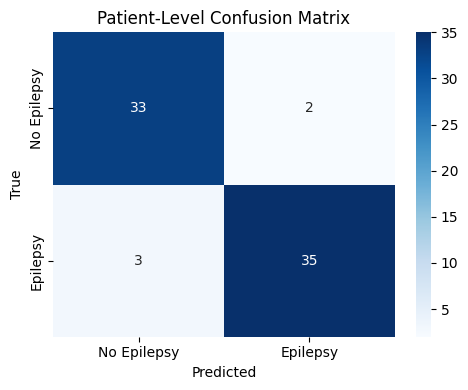

In [49]:
import os
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

# ==================== Setup ====================
RUN_NAME = 'EEGNet_Patient_Level'
EXPERIMENT_NAME = "Epilepsy_Classifiers"

# Set remote MLflow tracking server
os.environ["APP_URI"] = 'https://zacbl-dsfs33-mlflow.hf.space/'
mlflow.set_tracking_uri(os.environ["APP_URI"])
mlflow.set_experiment(EXPERIMENT_NAME)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Safe autolog: logs sklearn-compatible metrics only
mlflow.sklearn.autolog()

# ==================== Metrics Function ====================
def eval_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return acc, f1, precision, recall

# ==================== Start MLflow Run ====================
with mlflow.start_run(experiment_id=experiment.experiment_id):
    mlflow.set_tag('mlflow.runName', RUN_NAME)

    # ========== Aggregate segment-level → patient-level ==========
    agg_df = aggregate_predictions_dl(
        model=model,
        segment_df=df,
        feature_cols=[col for col in df.columns if col.startswith("EEG")],
        id_col='subject_id',
        label_col='epilepsy',
        threshold=0.5,
        device="cuda" if torch.cuda.is_available() else "cpu",
        batch_size=32
    )

    # ========== Evaluate metrics ==========
    y_true = agg_df["true_label"]
    y_pred = agg_df["predicted_label"]
    acc, f1, precision, recall = eval_metrics(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    # ========== Log metrics ==========
    mlflow.log_metric("Accuracy", acc)
    mlflow.log_metric("f1-score", f1)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("Specificity", specificity)

    # ========== Display metrics locally ==========
    print("📊 Patient-Level Metrics")
    print(f"- Accuracy:    {acc:.4f}")
    print(f"- Recall:      {recall:.4f}")
    print(f"- Specificity: {specificity:.4f}")
    print(f"- F1 Score:    {f1:.4f}")

    # ========== Save files locally only ==========
    # Save confusion matrix locally (but NOT logging to MLflow)
    conf_mat = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Epilepsy", "Epilepsy"],
                yticklabels=["No Epilepsy", "Epilepsy"])
    plt.title("Patient-Level Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")  # Local only

    # Save model locally using joblib
    model_dict = {
        "model_state_dict": model.state_dict(),
        "model_params": {
            "n_channels": 21,
            "n_samples": 1250,
            "num_classes": 2
        }
    }
    joblib.dump(model_dict, "eegnet_model.joblib")  # Local only

    print("✅ Saved 'confusion_matrix.png' and 'eegnet_model.joblib' locally.")
    mlflow.end_run()


In [23]:
df["epilepsy"].value_counts(normalize=True)


epilepsy
1    0.526316
0    0.473684
Name: proportion, dtype: float64

In [50]:
df.groupby('epilepsy')['epoch'].count()

epilepsy
0    468
1    558
Name: epoch, dtype: int64

In [ ]:
#torch.save(model.state_dict(), "eegnet_trained.pth") #save model 
